### 환경 설정

In [ ]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import koreanize_matplotlib
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120

### 데이터 로드

In [3]:
# 경로 설정 (로컬)
DATA_PATH = '../data/raw/'

# 경로 설정 (Colab)
# from google.colab import drive
# drive.mount('/content/drive')
# ROOT = '/content/drive/MyDrive/PREGNANCY-ML-MODELS'
# DATA_PATH = f'{ROOT}/data/raw/'

In [22]:
train = pd.read_csv(DATA_PATH + 'train.csv')
test  = pd.read_csv(DATA_PATH + 'test.csv')

print(f'Train shape : {train.shape}')
print(f'Test  shape : {test.shape}')

train.head(3)

print(train.columns)

Train shape : (256351, 69)
Test  shape : (90067, 68)
Index(['ID', '시술 시기 코드', '시술 당시 나이', '임신 시도 또는 마지막 임신 경과 연수', '시술 유형',
       '특정 시술 유형', '배란 자극 여부', '배란 유도 유형', '단일 배아 이식 여부', '착상 전 유전 검사 사용 여부',
       '착상 전 유전 진단 사용 여부', '남성 주 불임 원인', '남성 부 불임 원인', '여성 주 불임 원인',
       '여성 부 불임 원인', '부부 주 불임 원인', '부부 부 불임 원인', '불명확 불임 원인', '불임 원인 - 난관 질환',
       '불임 원인 - 남성 요인', '불임 원인 - 배란 장애', '불임 원인 - 여성 요인', '불임 원인 - 자궁경부 문제',
       '불임 원인 - 자궁내막증', '불임 원인 - 정자 농도', '불임 원인 - 정자 면역학적 요인',
       '불임 원인 - 정자 운동성', '불임 원인 - 정자 형태', '배아 생성 주요 이유', '총 시술 횟수',
       '클리닉 내 총 시술 횟수', 'IVF 시술 횟수', 'DI 시술 횟수', '총 임신 횟수', 'IVF 임신 횟수',
       'DI 임신 횟수', '총 출산 횟수', 'IVF 출산 횟수', 'DI 출산 횟수', '총 생성 배아 수',
       '미세주입된 난자 수', '미세주입에서 생성된 배아 수', '이식된 배아 수', '미세주입 배아 이식 수', '저장된 배아 수',
       '미세주입 후 저장된 배아 수', '해동된 배아 수', '해동 난자 수', '수집된 신선 난자 수', '저장된 신선 난자 수',
       '혼합된 난자 수', '파트너 정자와 혼합된 난자 수', '기증자 정자와 혼합된 난자 수', '난자 출처', '정자 출처',
       '난자 기증자 나이', '정자 기증자 나이', '동결 배아 사용 여부', '신선 배아 사용 여부', '기

### 타겟별 분포

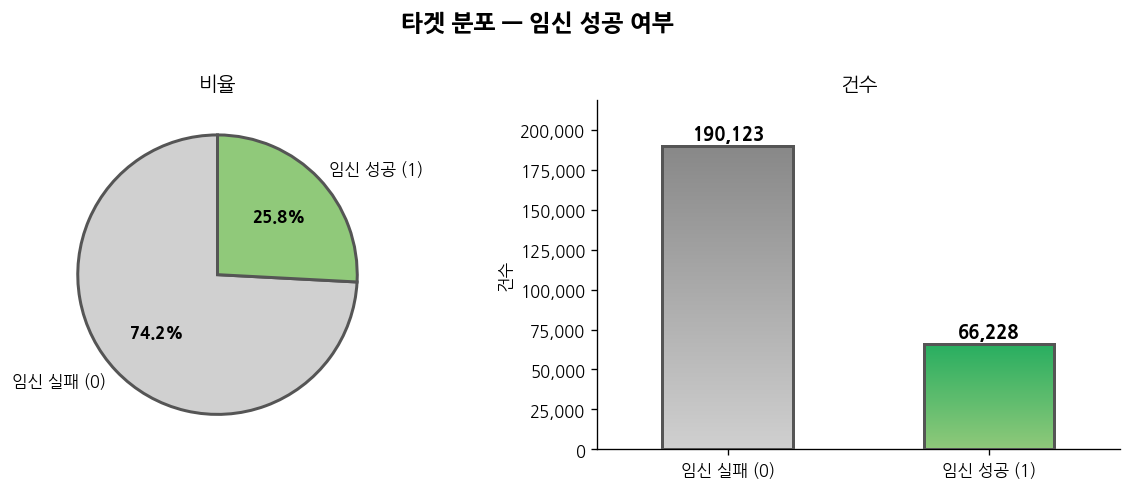


임신 성공률 : 25.83%
클래스 비율 (실패:성공) = 1 : 0.35


In [9]:
target = train['임신 성공 여부']
counts = target.value_counts().sort_index()
labels = ['임신 실패 (0)', '임신 성공 (1)']
grad_colors = [('#D0D0D0', '#888888'), ('#90C97A', '#27AE60')]  # 실패: 연회색→진회색, 성공: 연초록→진초록

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle('타겟 분포 — 임신 성공 여부', fontsize=14, fontweight='bold', y=1.01)

# 파이차트
wedges, texts, autotexts = axes[0].pie(
    counts, labels=labels,
    colors=[c[0] for c in grad_colors],
    autopct='%1.1f%%', startangle=90,
    wedgeprops={'edgecolor': '#555555', 'linewidth': 1.8}
)
for autotext in autotexts:
    autotext.set_fontweight('bold')
axes[0].set_title('비율')

# 바차트 — 그라데이션
def gradient_bar(ax, x, height, color_top, color_bottom, width=0.5):
    import matplotlib.colors as mcolors
    grad = np.linspace(0, 1, 256).reshape(-1, 1)
    c_bottom = mcolors.to_rgba(color_bottom)
    c_top    = mcolors.to_rgba(color_top)
    img = np.array([[
        tuple(c_bottom[i] * (1 - t) + c_top[i] * t for i in range(4))
        for t in row
    ] for row in grad])
    ax.imshow(img, aspect='auto', origin='lower',
              extent=[x - width/2, x + width/2, 0, height], zorder=2)
    rect = plt.Rectangle((x - width/2, 0), width, height,
                          fill=False, edgecolor='#555555', linewidth=1.8, zorder=3)
    ax.add_patch(rect)

for i, (label, val) in enumerate(zip(labels, counts.values)):
    gradient_bar(axes[1], i, val,
                 color_top=grad_colors[i][1],
                 color_bottom=grad_colors[i][0])
    axes[1].text(i, val + 4000, f'{val:,}',
                 ha='center', fontsize=11, fontweight='bold', zorder=4)

axes[1].set_title('건수')
axes[1].set_ylabel('건수')
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(labels)
axes[1].set_xlim(-0.5, 1.5)
axes[1].set_ylim(0, counts.max() * 1.15)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
sns.despine(ax=axes[1])

plt.tight_layout()
plt.show()

print(f'\n임신 성공률 : {target.mean()*100:.2f}%')
print(f'클래스 비율 (실패:성공) = 1 : {counts[1]/counts[0]:.2f}')

### 결측치 현황

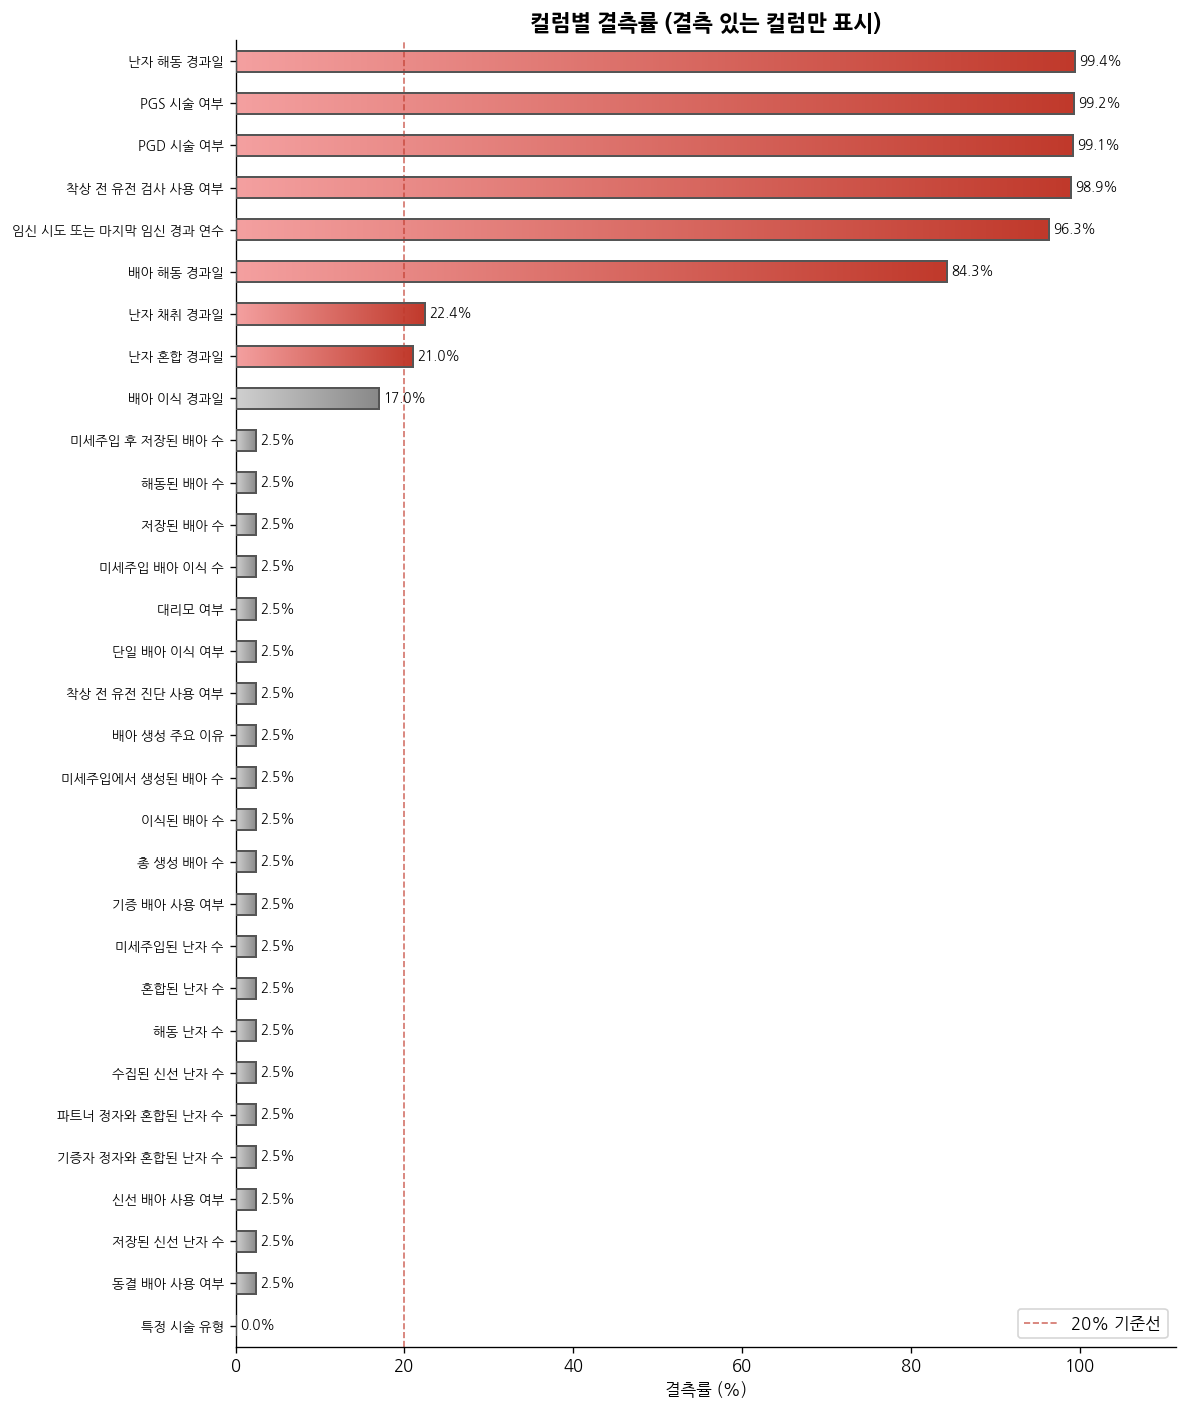


결측 컬럼 수 : 31 / 69
결측률 50% 이상 : 6개
결측률 20~50%  : 2개
결측률 20% 미만 : 23개


In [10]:
missing = (train.isnull().sum() / len(train) * 100).sort_values(ascending=False)
missing = missing[missing > 0]

# 결측률 높을수록 붉은색, 낮을수록 회색
grad_configs = {
    'high': ('#F4A0A0', '#C0392B'),  # 연빨강 → 진빨강
    'low':  ('#D0D0D0', '#888888'),  # 연회색 → 진회색
}

def get_grad(val):
    if val >= 20: return grad_configs['high']
    return grad_configs['low']

def gradient_barh(ax, y, width, color_left, color_right, height=0.5):
    import matplotlib.colors as mcolors
    grad = np.linspace(0, 1, 256).reshape(1, -1)
    c_l = mcolors.to_rgba(color_left)
    c_r = mcolors.to_rgba(color_right)
    img = np.array([[
        tuple(c_l[i] * (1 - t) + c_r[i] * t for i in range(4))
        for t in row
    ] for row in grad])
    ax.imshow(img, aspect='auto', origin='lower',
              extent=[0, width, y - height/2, y + height/2], zorder=2)
    rect = plt.Rectangle((0, y - height/2), width, height,
                          fill=False, edgecolor='#555555', linewidth=1.2, zorder=3)
    ax.add_patch(rect)

fig, ax = plt.subplots(figsize=(10, len(missing) * 0.35 + 1))

for i, (col, val) in enumerate(zip(missing.index, missing.values)):
    c_left, c_right = get_grad(val)
    gradient_barh(ax, i, val, c_left, c_right)
    ax.text(val + 0.5, i, f'{val:.1f}%', va='center', fontsize=8, zorder=4)

ax.axvline(20, color='#C0392B', linestyle='--', linewidth=1, alpha=0.7, label='20% 기준선')
ax.set_yticks(range(len(missing)))
ax.set_yticklabels(missing.index, fontsize=8)
ax.set_xlabel('결측률 (%)')
ax.set_title('컬럼별 결측률 (결측 있는 컬럼만 표시)', fontsize=13, fontweight='bold')
ax.set_xlim(0, missing.max() * 1.12)
ax.set_ylim(-0.5, len(missing) - 0.5)
ax.invert_yaxis()
ax.legend(loc='lower right')
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

print(f'\n결측 컬럼 수 : {len(missing)} / {train.shape[1]}')
print(f'결측률 50% 이상 : {(missing >= 50).sum()}개')
print(f'결측률 20~50%  : {((missing >= 20) & (missing < 50)).sum()}개')
print(f'결측률 20% 미만 : {(missing < 20).sum()}개')

### 범주형 변수별 임신 성공률

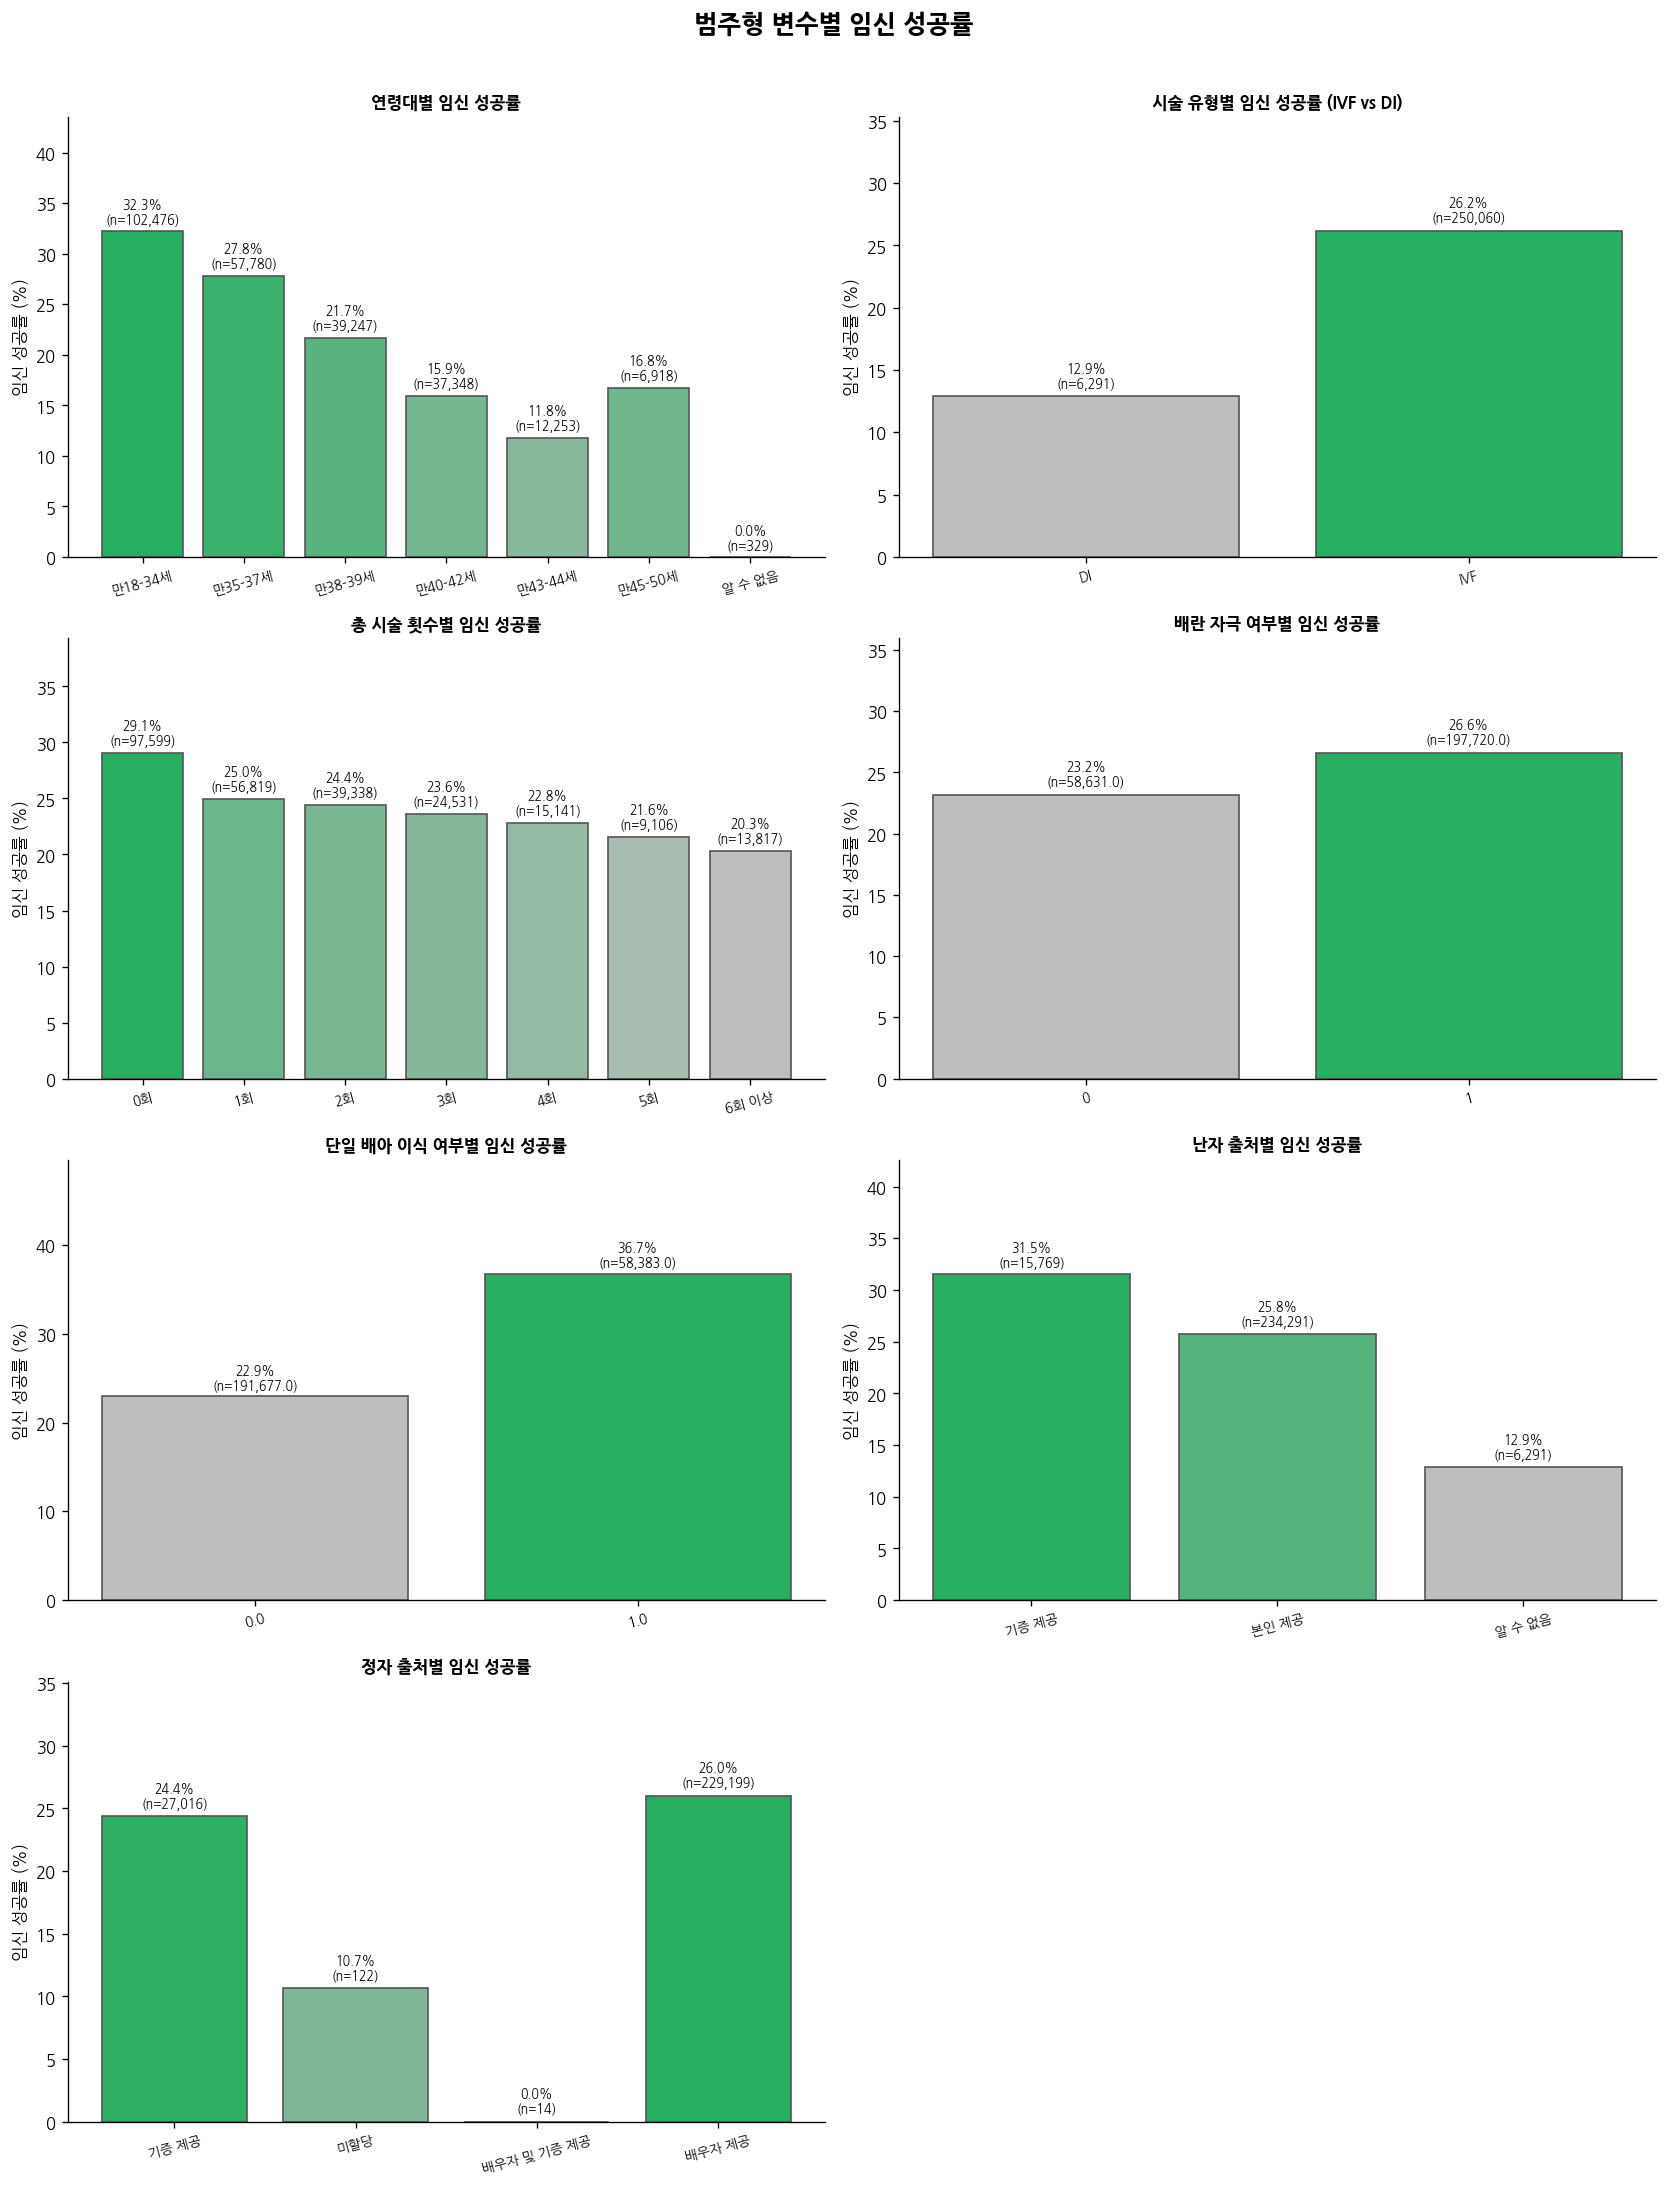

In [8]:
import matplotlib.cm as cm
import matplotlib.colors as mcolors

age_order = ['만18-34세', '만35-37세', '만38-39세', '만40-42세', '만43-44세', '만45-50세', '알 수 없음']
count_order = ['0회', '1회', '2회', '3회', '4회', '5회', '6회 이상']

cat_configs = [
    ('시술 당시 나이',      age_order,   '연령대별 임신 성공률'),
    ('시술 유형',           None,        '시술 유형별 임신 성공률 (IVF vs DI)'),
    ('총 시술 횟수',        count_order, '총 시술 횟수별 임신 성공률'),
    ('배란 자극 여부',      None,        '배란 자극 여부별 임신 성공률'),
    ('단일 배아 이식 여부', None,        '단일 배아 이식 여부별 임신 성공률'),
    ('난자 출처',           None,        '난자 출처별 임신 성공률'),
    ('정자 출처',           None,        '정자 출처별 임신 성공률'),
]

# 회색 → 초록 커스텀 컬러맵
gray_green = mcolors.LinearSegmentedColormap.from_list(
    'gray_green', ['#BEBEBE', '#27AE60']
)

fig, axes = plt.subplots(4, 2, figsize=(14, 18))
axes = axes.flatten()
fig.suptitle('범주형 변수별 임신 성공률', fontsize=15, fontweight='bold', y=1.01)

for i, (col, order, title) in enumerate(cat_configs):
    ax = axes[i]
    grp = train.groupby(col, observed=True)['임신 성공 여부'].agg(['mean', 'count']).reset_index()
    grp.columns = [col, 'rate', 'count']

    if order:
        grp[col] = pd.Categorical(grp[col], categories=order, ordered=True)
        grp = grp.sort_values(col)
    norm = mcolors.Normalize(vmin=grp['rate'].min(), vmax=grp['rate'].max())
    colors = [gray_green(norm(r)) for r in grp['rate']]

    bars = ax.bar(grp[col].astype(str), grp['rate'] * 100,
                  color=colors, edgecolor='#555555', linewidth=1.0)

    for bar, (_, row) in zip(bars, grp.iterrows()):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f"{row['rate']*100:.1f}%\n(n={row['count']:,})",
                ha='center', va='bottom', fontsize=7.5)

    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_ylabel('임신 성공률 (%)')
    ax.set_ylim(0, grp['rate'].max() * 100 * 1.35)
    ax.tick_params(axis='x', labelsize=8, rotation=15)
    sns.despine(ax=ax)

axes[-1].set_visible(False)
plt.tight_layout()
plt.show()

### 수치형 변수 이상치

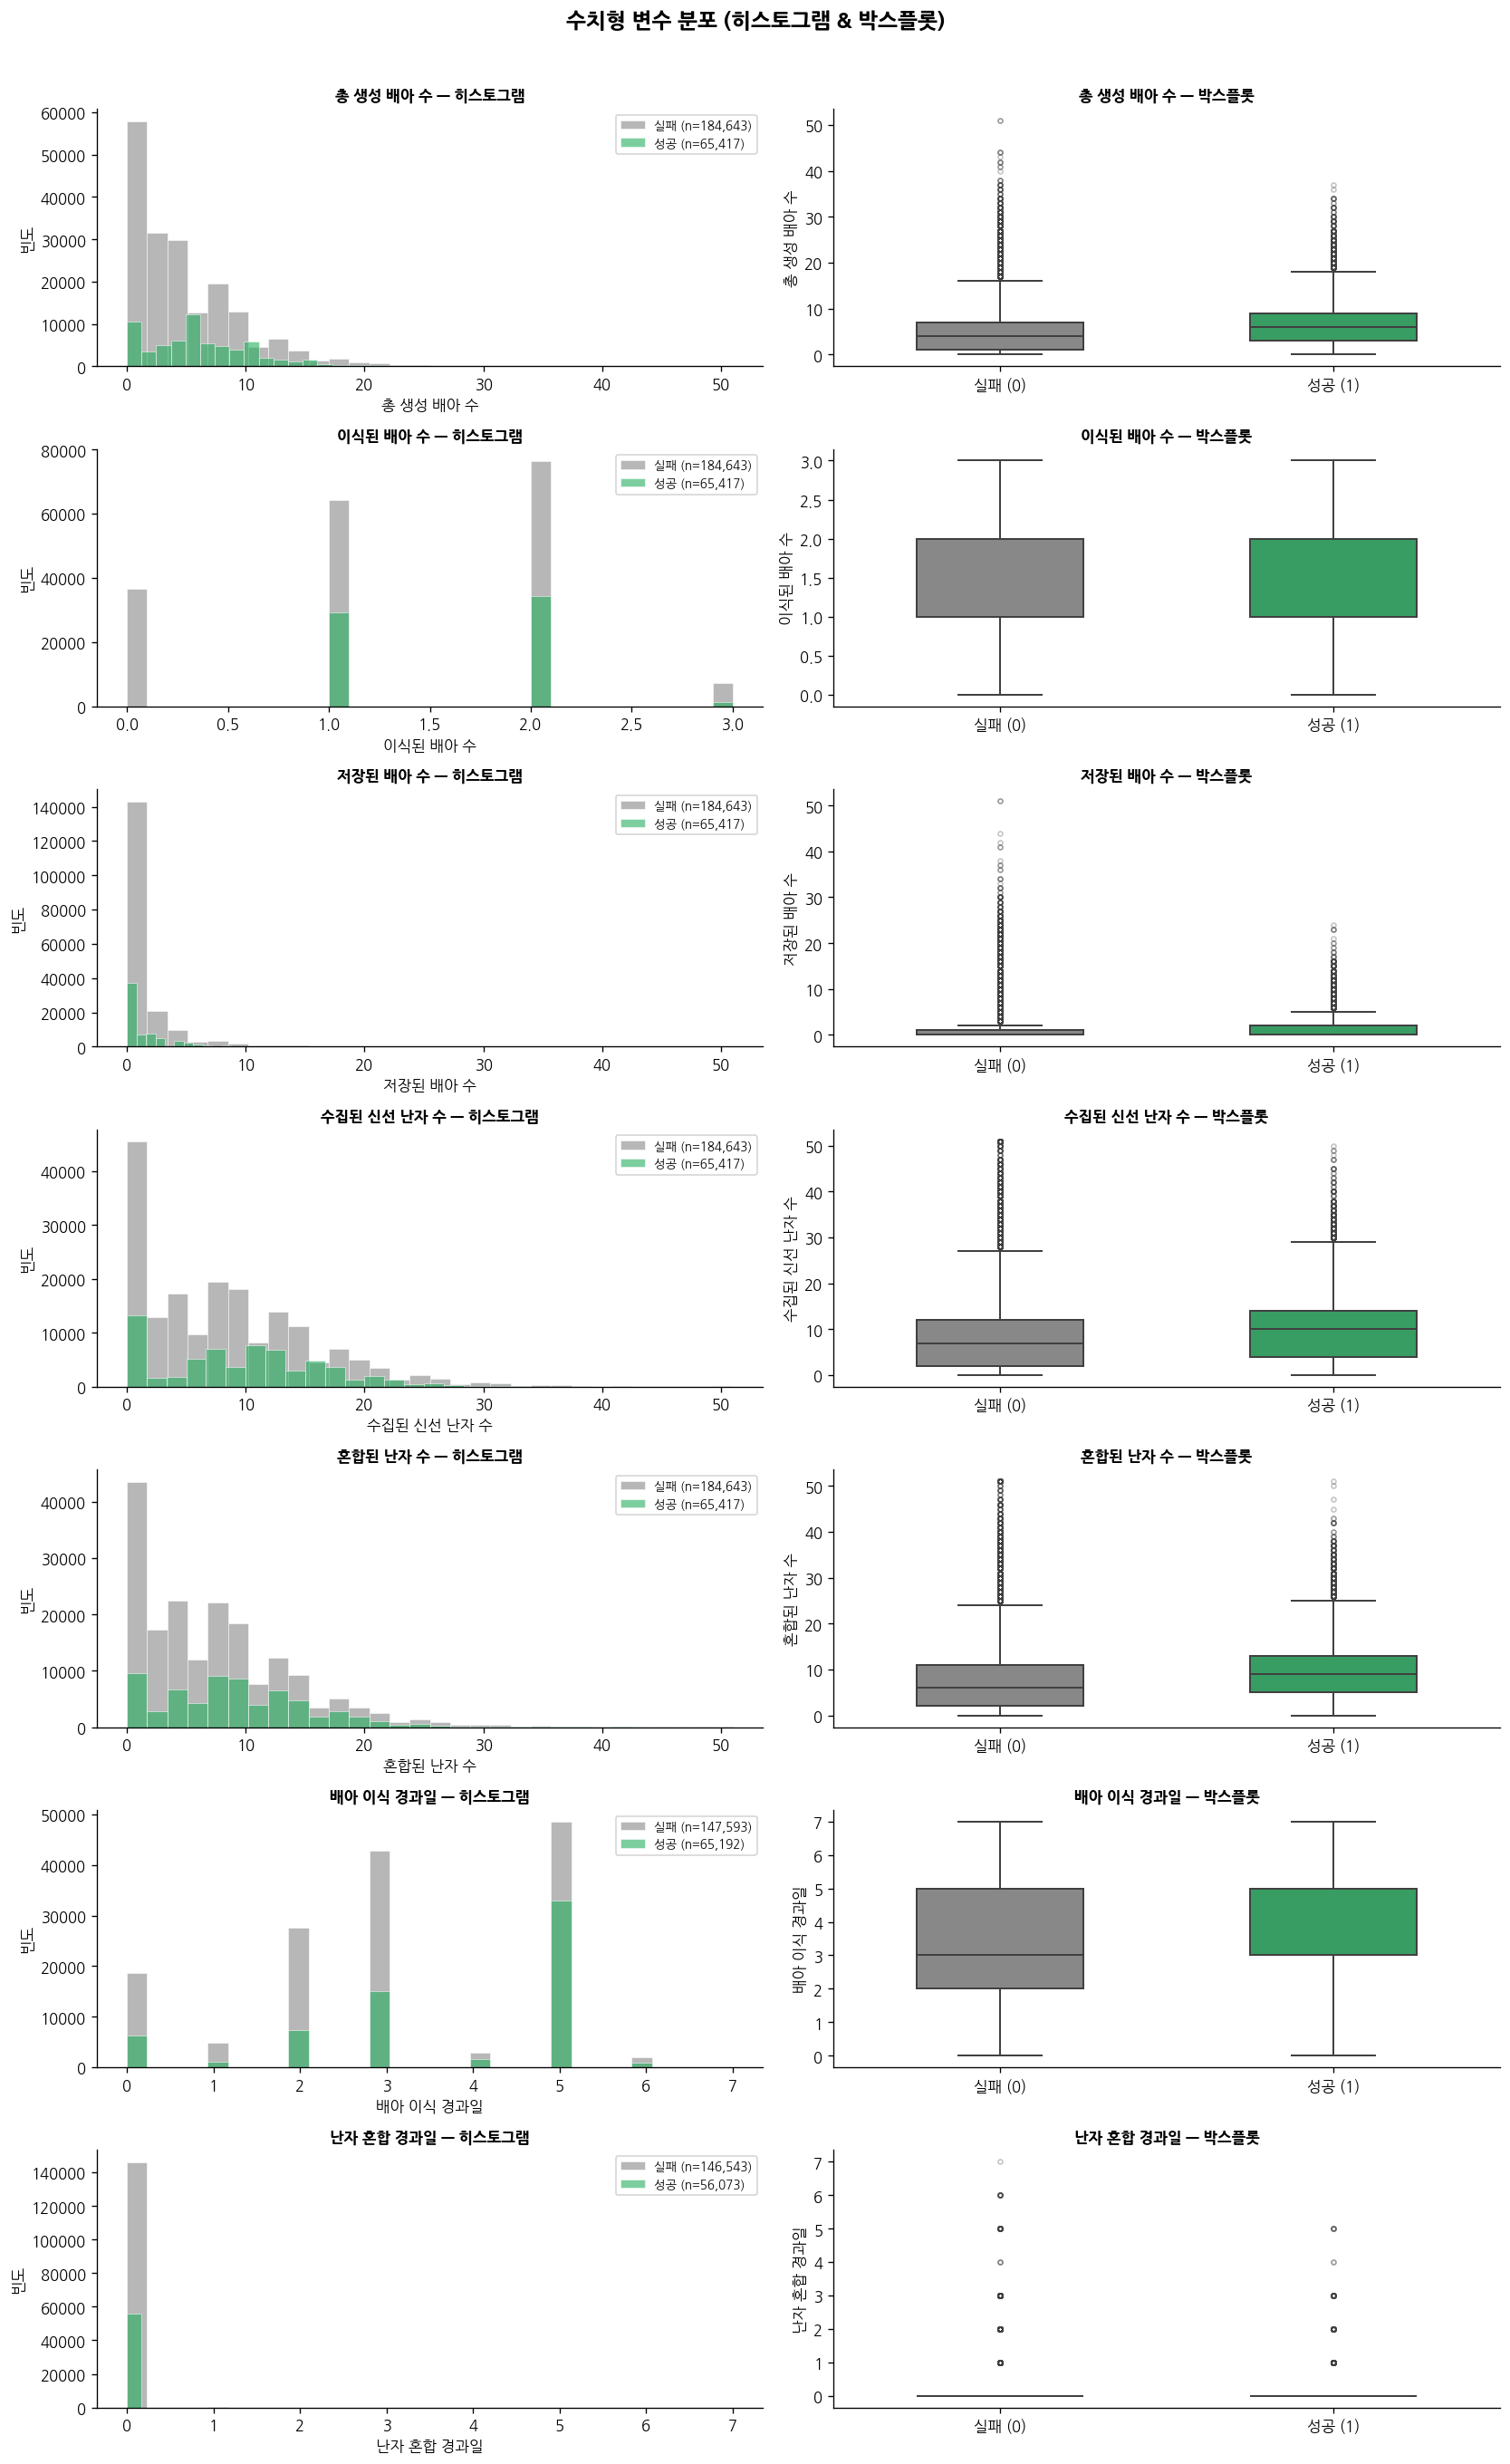


── 수치형 변수 기술통계 ──


,총 생성 배아 수,이식된 배아 수,저장된 배아 수,수집된 신선 난자 수,혼합된 난자 수,배아 이식 경과일,난자 혼합 경과일
count,250060.00,250060.00,250060.00,250060.00,250060.00,212785.00,202616.00
mean,5.06,1.37,1.19,8.56,7.70,3.25,0.01
std,4.66,0.77,2.50,7.32,6.45,1.72,0.11
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,1.00,1.00,0.00,2.00,3.00,2.00,0.00
50%,4.00,1.00,0.00,8.00,7.00,3.00,0.00
75%,8.00,2.00,2.00,13.00,11.00,5.00,0.00
max,51.00,3.00,51.00,51.00,51.00,7.00,7.00


In [12]:
num_cols = [
    '총 생성 배아 수', '이식된 배아 수', '저장된 배아 수',
    '수집된 신선 난자 수', '혼합된 난자 수',
    '배아 이식 경과일', '난자 혼합 경과일'
]

fig, axes = plt.subplots(len(num_cols), 2, figsize=(14, len(num_cols) * 3.2))
fig.suptitle('수치형 변수 분포 (히스토그램 & 박스플롯)', fontsize=14, fontweight='bold', y=1.01)

palette = {'0': '#888888', '1': '#27AE60'}  # 실패: 회색, 성공: 초록

for i, col in enumerate(num_cols):
    data = train[[col, '임신 성공 여부']].dropna()
    data['임신 성공 여부'] = data['임신 성공 여부'].astype(str)

    # 히스토그램
    ax_hist = axes[i][0]
    for val, color in palette.items():
        subset = data[data['임신 성공 여부'] == val][col]
        ax_hist.hist(subset, bins=30, alpha=0.6, color=color,
                     label=f"{'성공' if val == '1' else '실패'} (n={len(subset):,})",
                     edgecolor='white', linewidth=0.5)
    ax_hist.set_title(f'{col} — 히스토그램', fontsize=10, fontweight='bold')
    ax_hist.set_xlabel(col)
    ax_hist.set_ylabel('빈도')
    ax_hist.legend(fontsize=8)
    sns.despine(ax=ax_hist)

    # 박스플롯
    ax_box = axes[i][1]
    sns.boxplot(
        data=data, x='임신 성공 여부', y=col, ax=ax_box,
        palette=palette, width=0.5, linewidth=1.2,
        flierprops={'marker': 'o', 'markersize': 3, 'alpha': 0.3}
    )
    ax_box.set_xticklabels(['실패 (0)', '성공 (1)'])
    ax_box.set_title(f'{col} — 박스플롯', fontsize=10, fontweight='bold')
    ax_box.set_xlabel('')
    sns.despine(ax=ax_box)

plt.tight_layout()
plt.show()

# 기술통계
print('\n── 수치형 변수 기술통계 ──')
train[num_cols].describe().round(2)

### 피처 간 상관관계

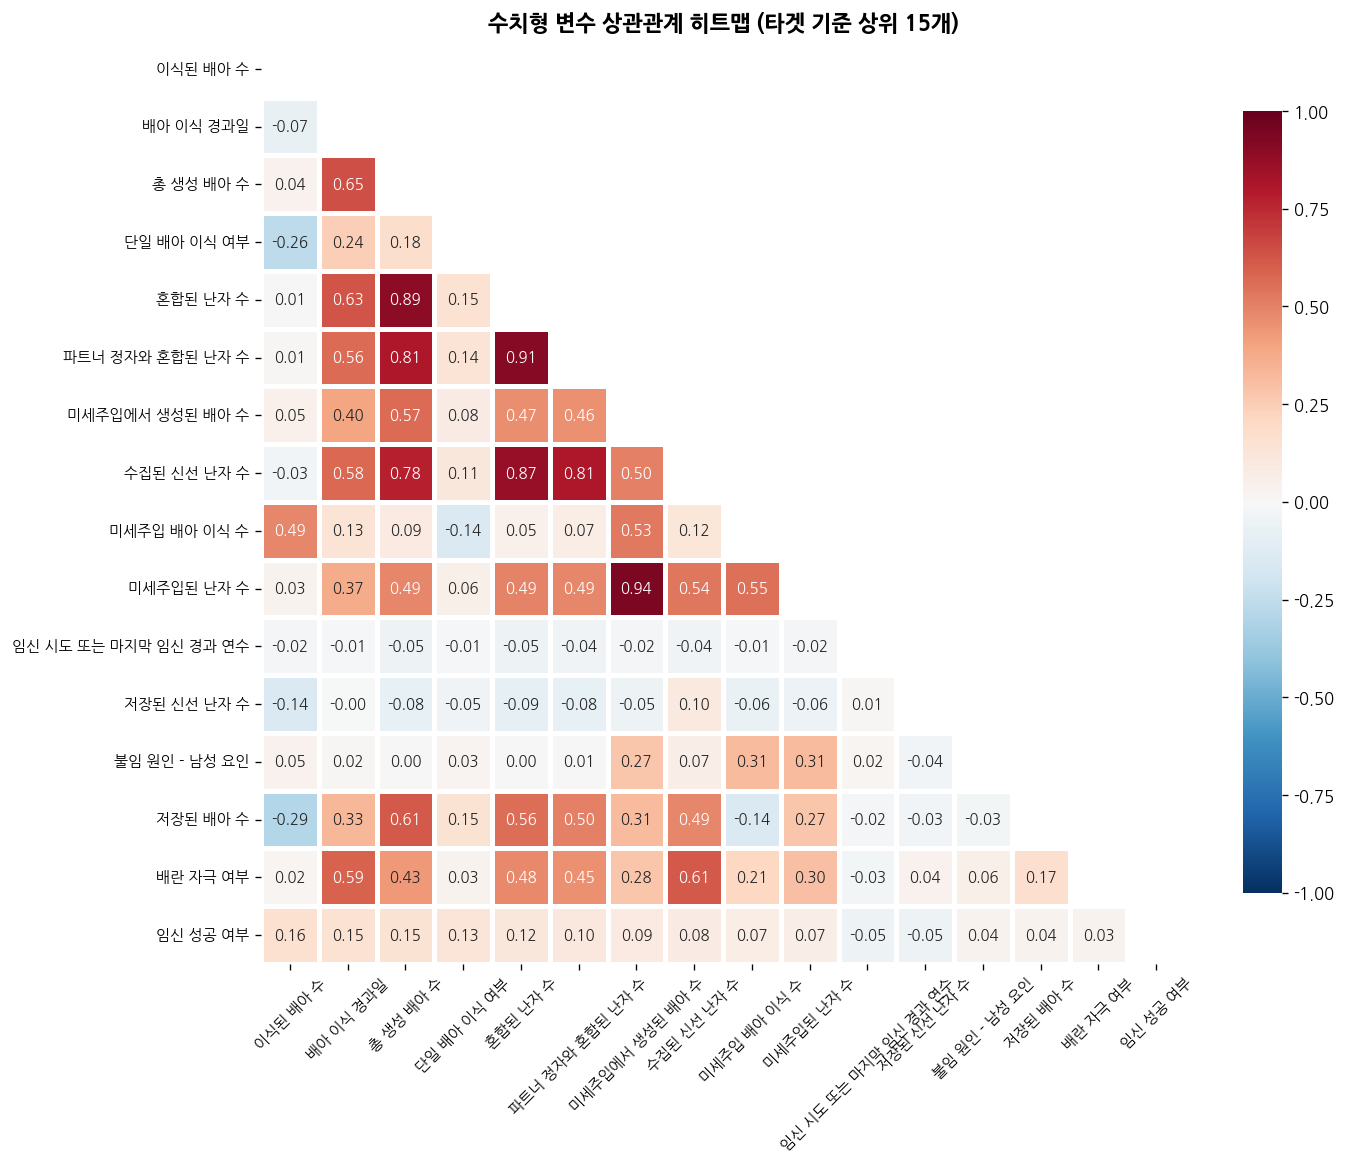

In [ ]:
num_all = train.select_dtypes(include='number').columns.tolist()
corr = train[num_all].corr()

top_cols = corr['임신 성공 여부'].drop('임신 성공 여부').abs().sort_values(ascending=False).head(15).index.tolist()
top_cols = top_cols + ['임신 성공 여부']
corr_top = corr.loc[top_cols, top_cols]

mask = np.triu(np.ones_like(corr_top, dtype=bool))

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    corr_top, mask=mask, ax=ax,
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    annot=True, fmt='.2f', annot_kws={'size': 9},
    linewidths=3, linecolor='white', 
    square=True, cbar_kws={'shrink': 0.8}
)
ax.set_title('수치형 변수 상관관계 히트맵 (타겟 기준 상위 15개)', fontsize=13, fontweight='bold')
ax.tick_params(axis='x', rotation=45, labelsize=9)
ax.tick_params(axis='y', rotation=0, labelsize=9)
plt.tight_layout()
plt.show()

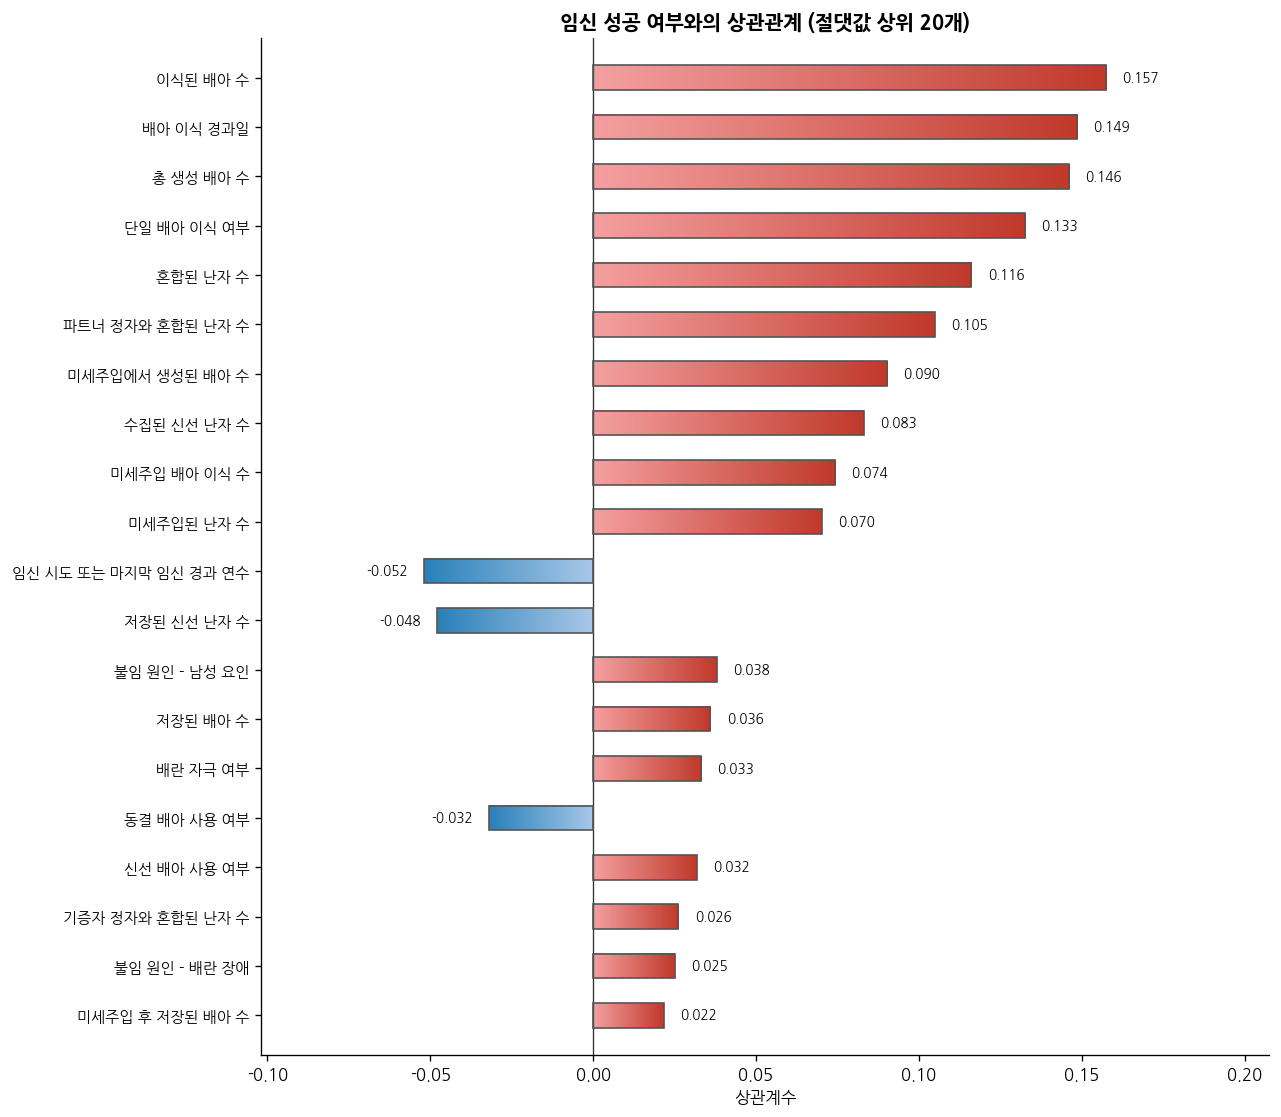

In [18]:
target_corr = corr['임신 성공 여부'].drop('임신 성공 여부').sort_values(key=abs, ascending=False).head(20)

def gradient_barh(ax, y, width, color_left, color_right, height=0.5):
    import matplotlib.colors as mcolors
    grad = np.linspace(0, 1, 256).reshape(1, -1)
    c_l = mcolors.to_rgba(color_left)
    c_r = mcolors.to_rgba(color_right)
    img = np.array([[
        tuple(c_l[i] * (1 - t) + c_r[i] * t for i in range(4))
        for t in row
    ] for row in grad])
    start = min(0, width)
    end   = max(0, width)
    ax.imshow(img if width >= 0 else img[:, ::-1], aspect='auto', origin='lower',
              extent=[start, end, y - height/2, y + height/2], zorder=2)
    rect = plt.Rectangle((start, y - height/2), abs(width), height,
                          fill=False, edgecolor='#555555', linewidth=1.0, zorder=3)
    ax.add_patch(rect)

fig, ax = plt.subplots(figsize=(12, len(target_corr) * 0.5 + 1))

for i, (col, val) in enumerate(target_corr.items()):
    if val >= 0:
        gradient_barh(ax, i, val, '#F4A0A0', '#C0392B')
    else:
        gradient_barh(ax, i, val, '#A8C8E8', '#2980B9')

    ax.text(val + (0.005 if val >= 0 else -0.005), i,
            f'{val:.3f}', va='center',
            ha='left' if val >= 0 else 'right', fontsize=8, zorder=4)

ax.axvline(0, color='#333333', linewidth=0.8)
ax.set_yticks(range(len(target_corr)))
ax.set_yticklabels(target_corr.index, fontsize=9)
ax.set_xlabel('상관계수')
ax.set_title('임신 성공 여부와의 상관관계 (절댓값 상위 20개)', fontsize=12, fontweight='bold')
ax.set_xlim(target_corr.min() - 0.05, target_corr.max() + 0.05)  # 고정 여백
ax.set_ylim(-0.8, len(target_corr) - 0.2)
ax.invert_yaxis()
sns.despine(ax=ax)
fig.subplots_adjust(left=0.25, right=0.95)  # 좌우 여백 명시적으로 설정
plt.show()